<a href="https://colab.research.google.com/github/lenmecc/miniature-enigma/blob/main/Analisis_uso_placas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Analisis de uso de placas 2026 - Apodaca.**
EXPLORACIÓN DE DATOS. **07 DE ENERO DE 2026**


**OBJETIVO:**


1. Ejecutar acciones de limpieza, tranformación de la base de datios.
Validando y entendiendo la frecuencia de uso de las placas usadas durante en año 2026 en planta 2

In [ ]:
from google.colab import files
# Subir placas p2.xlsx
uploaded = files.upload()

Saving placas p2.xlsx to placas p2.xlsx


In [ ]:
import pandas as pd
df = pd.read_excel('placas p2.xlsx')
df.head()

,DemandaEPS,Planta,Fecha,Placa,Peso
0,2357497,2,2025-01-01,ALLM14-52H3248120,5.4960
1,2357429,2,2025-01-01,AILM14--3042B48065,1.6371
2,2357317,2,2025-01-01,ALLM13-52H3248120,115.2768
3,2357444,2,2025-01-01,ALLM1/8-52H3248120,0.5760
4,2357510,2,2025-01-01,ALLM125052H3248120,2.8730


In [ ]:
#Antes de comenzar, importemos algunas librerías necesarias
#Preescindamos de los warnings al correor nuestro código
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

Comenzemos con la validación usando el Check list.

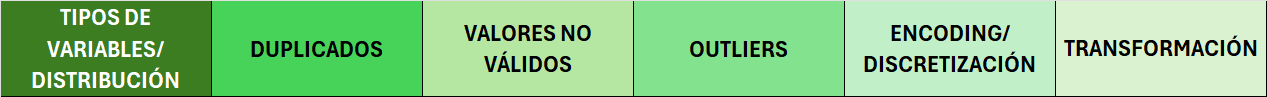



In [ ]:
#Tipos de variables

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35309 entries, 0 to 35308
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   DemandaEPS  35309 non-null  int64         
 1   Planta      35309 non-null  int64         
 2   Fecha       35309 non-null  datetime64[ns]
 3   Placa       35309 non-null  object        
 4   Peso        35309 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 1.3+ MB


In [ ]:
#Detectar duplicados

# Descubriendo si registros duplicados
duplicated_rows = df[df.duplicated()]
num_duplicated_rows = df.duplicated().sum()

# Mostrando el resultado de la evaluación
print("Registros duplicados:")
print(num_duplicated_rows)

Registros duplicados:
0


In [ ]:
#Analizar distribuciones

Cuartiles y RIQ:
- Q1 (25%): 2.72
- Mediana (Q2): 11.0035
- Q3 (75%): 45.72
- Rango Intercuartílico (RIQ): 43.0
- Límite inferior: -61.78
- Límite superior: 110.22

Ejemplos de valores atípicos (primeros 10):
[115.2768 170.22   338.1408 347.4    113.6096 167.644  122.4    229.144
 269.76   401.792 ]


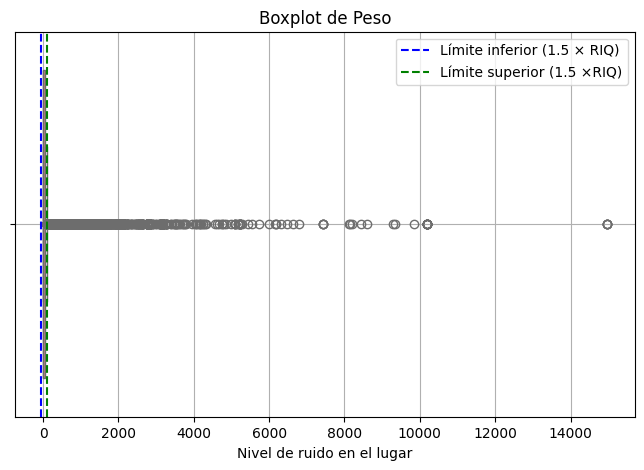

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns


# Seleccionar y limpiar la variable Noise atPlace
noise_data = df['Peso'].dropna()

# Calcular cuartiles y RIQ
Q1 = np.percentile(noise_data, 25)
Q2 = np.percentile(noise_data, 50)  # Mediana
Q3 = np.percentile(noise_data, 75)
RIQ = Q3 - Q1

# Calcular límites según la regla 1.5 × RIQ
# Podemos cambiar el multiplicados, sustituyendo el 1.5 por 3
mult = 1.5
limite_inferior = Q1 - mult * RIQ
limite_superior = Q3 + mult * RIQ

# Identificar outliers
outliers = noise_data[(noise_data < limite_inferior) | (noise_data > limite_superior)]

# Mostrar resumen por consola
print("Cuartiles y RIQ:")
print(f"- Q1 (25%): {Q1}")
print(f"- Mediana (Q2): {Q2}")
print(f"- Q3 (75%): {Q3}")
print(f"- Rango Intercuartílico (RIQ): {RIQ}")
print(f"- Límite inferior: {limite_inferior}")
print(f"- Límite superior: {limite_superior}\n")

print("Ejemplos de valores atípicos (primeros 10):")
print(outliers.values[:10])

# Graficar boxplot y añadir líneas con los límites manuales
plt.figure(figsize=(8, 5))
sns.boxplot(x=noise_data, orient='h', color='salmon')

# Agregar líneas verticales para los límites calculados manualmente

plt.axvline(limite_inferior, color='blue', linestyle='--', label=f'Límite inferior ({mult} × RIQ)')
plt.axvline(limite_superior, color='green', linestyle='--', label=f'Límite superior ({mult} ×RIQ)')

plt.title('Boxplot de Peso')
plt.xlabel('Nivel de ruido en el lugar')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Mientras hacemos un análisis univariado de variables numéricas, queremos estudiar su tendencia central y dispersión.
# Generemos una función que nos ayudará a crear un diagrama de caja y un histograma para cualquier variable numérica de entrada.
# Esta función toma la columna numérica como entrada y devuelve los diagramas de caja y los histogramas para la variable.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=True, bins=None, mult=1.5):
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize)

    # Calcula percentiles y límites basados en el RIQ
    q1 = data[feature].quantile(0.25)
    q3 = data[feature].quantile(0.75)
    iqr = q3 - q1
    mult = 1.5
    lower_bound = q1 - mult * iqr
    upper_bound = q3 + mult * iqr

    # Boxplot
    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color="blue")

    # Histograma
    if bins:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="spring")
    else:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2)

    # Líneas verticales para media, mediana y límites
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--", label="Media")
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-", label="Mediana")
    ax_hist2.axvline(lower_bound, color='blue', linestyle='--', label=f'Límite inferior ({mult}×RIQ)')
    ax_hist2.axvline(upper_bound, color='red', linestyle='--', label=f'Límite superior ({mult}×RIQ)')

    ax_hist2.legend()
    plt.tight_layout()
    plt.show()

Diagrama para DemandaEPS


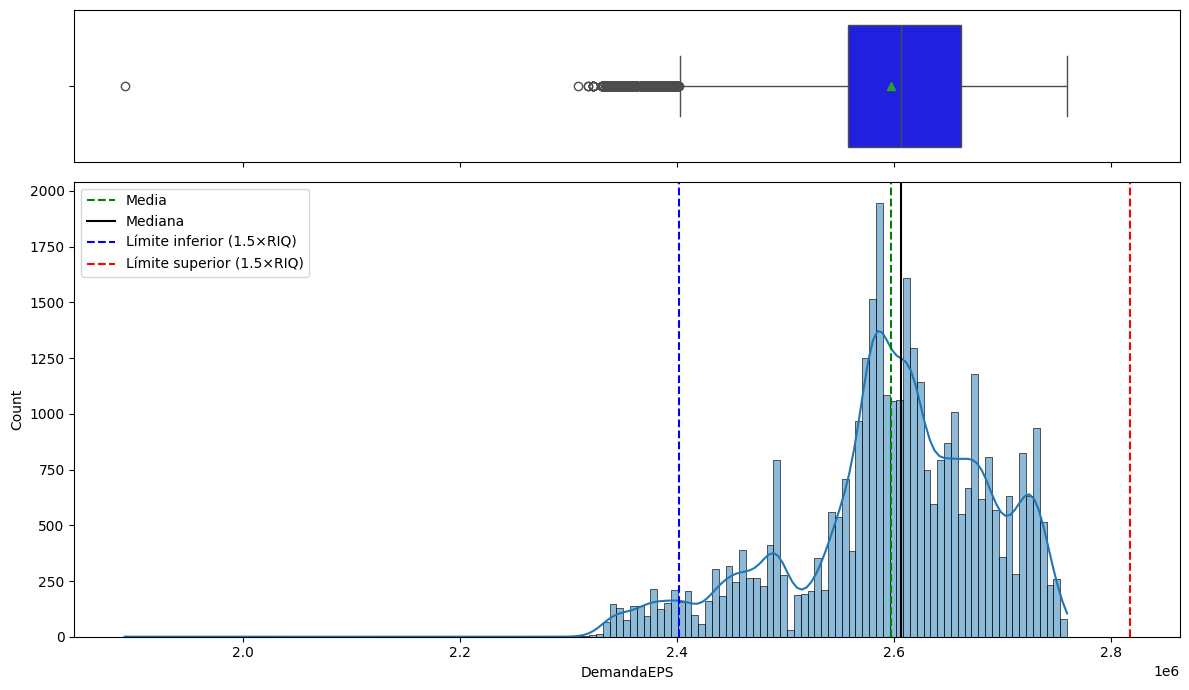

Diagrama para Planta


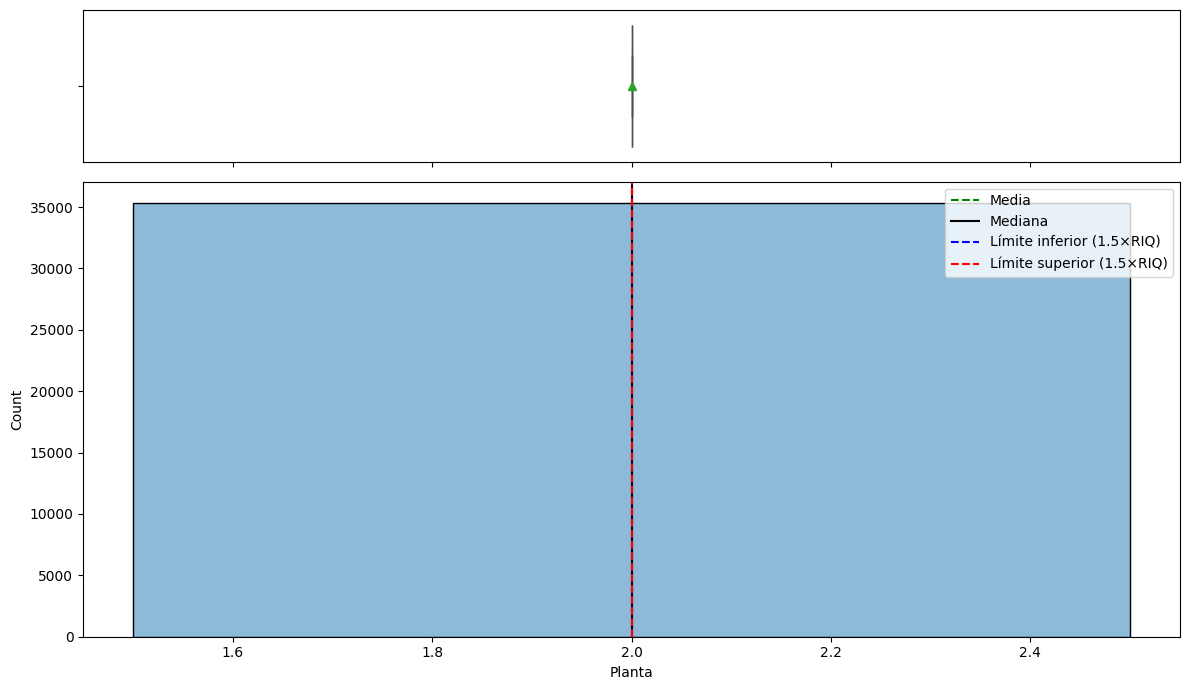

Diagrama para Peso


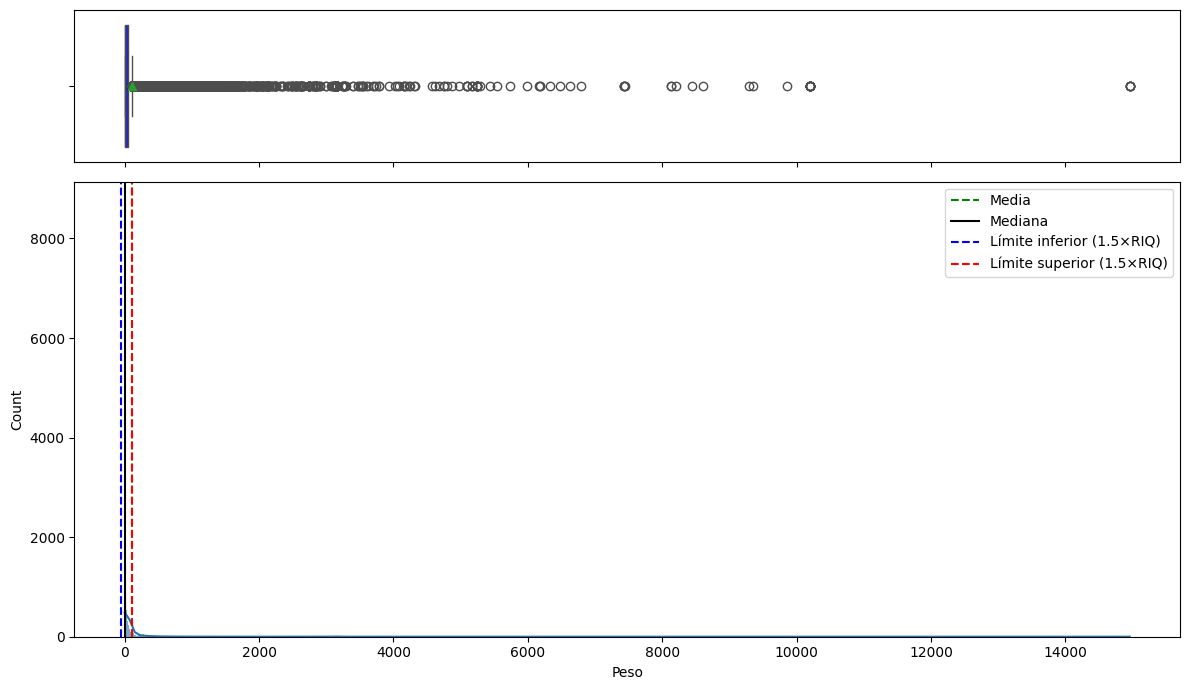

In [ ]:

# Apliquemos la función a las variables numéricas
# Seleccionando todas las columnas numéricas
numeric_columns = df.select_dtypes(include=[np.number]).columns

plt.close('all')
# Aplicar la función a todas las columnas numéricas
for col in numeric_columns:
    print(f"Diagrama para {col}")
    histogram_boxplot(df, col)

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
DemandaEPS,35309.0,2597284.635617,1891055.0,2557691.0,2605931.0,2661453.0,2759355.0,91010.91809
Planta,35309.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0
Fecha,35309,2025-07-01 23:27:24.872412160,2025-01-01 00:00:00,2025-04-07 00:00:00,2025-07-02 00:00:00,2025-10-01 00:00:00,2025-12-31 00:00:00,NaN
Peso,35309.0,108.371482,0.0,2.72,11.0035,45.72,14960.0,481.388881


In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.ensemble import IsolationForest

In [ ]:
# Definiendo el modelo para Unit_price
random_state = 42
model = IsolationForest(n_estimators=100, max_samples=100, contamination=0.005, random_state=random_state)
model.fit(df[['Peso']])
df.loc[:, 'scores'] = model.decision_function(df[['Peso']])
df.loc[:, 'anomaly_score'] = model.predict(df[['Peso']])

print("=====================================================================")
print("Resultados para variable: Peso ")
print("=====================================================================")
print(df[df['anomaly_score'] == -1])

Resultados para variable: Peso 
       DemandaEPS  Planta      Fecha                Placa       Peso  \
452       2555632       2 2025-01-06   ACLM12-1008DC48106   8135.856   
473       2554267       2 2025-01-06  AG141008C90MFA32090   8602.500   
1089      2554366       2 2025-01-13  AG141008C90MFA32090   5994.000   
3008      2572782       2 2025-02-03  AG141008C90MFA32090   5439.000   
3678      2572794       2 2025-02-10  AG141008C90MFA32090   8130.750   
...           ...     ...        ...                  ...        ...   
33677     2725617       2 2025-12-05   ACLM12-1008DC48092  10200.000   
33790     2719892       2 2025-12-08   ACLM12-1008DC48120   5239.200   
34299     2725605       2 2025-12-12   ACLM12-1008DC48092  10200.000   
34787     2734492       2 2025-12-22   ACLM12-1008DC48092   3400.000   
34965     2734484       2 2025-12-29   ACLM12-1008DC48092   3400.000   

         scores  anomaly_score    color  
452   -0.013476             -1  tab:red  
473   -0.013476    

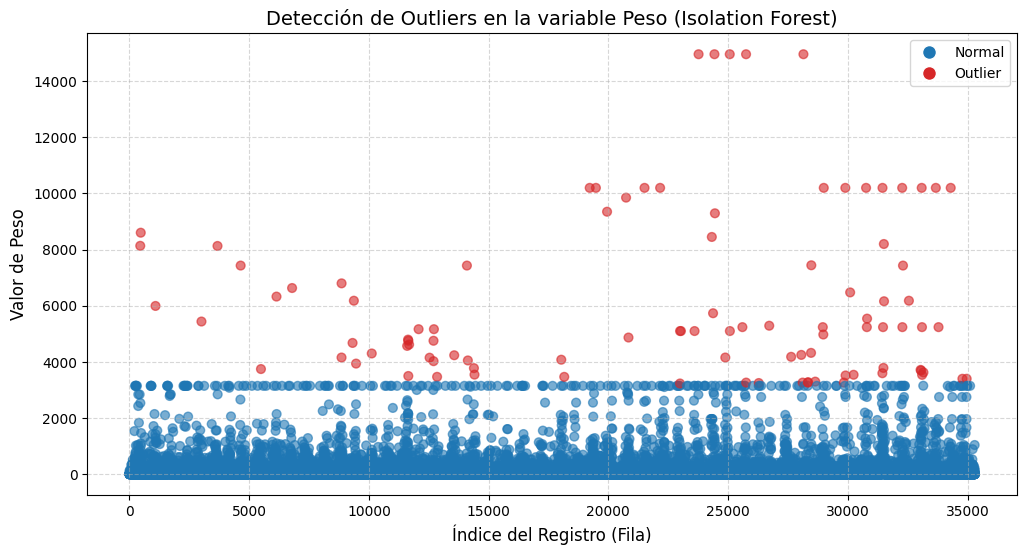

Resumen de valores detectados como outliers:
count       98.000000
mean      6208.402582
std       3044.605049
min       3232.250000
25%       3962.113750
50%       5166.240000
75%       7958.687500
max      14960.000000
Name: Peso, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creamos una columna de color para identificar visualmente los outliers
# '1' será azul (normal) y '-1' será rojo (anomalía)
df['color'] = df['anomaly_score'].map({1: 'tab:blue', -1: 'tab:red'})

plt.figure(figsize=(12, 6))

# 2. Graficamos los puntos
# Usamos el índice del DataFrame en el eje X y el Peso en el eje Y
plt.scatter(df.index, df['Peso'], c=df['color'], alpha=0.6, s=40, label='Datos')

# 3. Añadimos títulos y etiquetas
plt.title('Detección de Outliers en la variable Peso (Isolation Forest)', fontsize=14)
plt.xlabel('Índice del Registro (Fila)', fontsize=12)
plt.ylabel('Valor de Peso', fontsize=12)

# 4. Creamos una leyenda personalizada
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Normal',
                          markerfacecolor='tab:blue', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Outlier',
                          markerfacecolor='tab:red', markersize=10)]
plt.legend(handles=legend_elements, loc='upper right')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 5. Resumen estadístico de lo que detectamos
print("Resumen de valores detectados como outliers:")
print(df[df['anomaly_score'] == -1]['Peso'].describe())